In [1]:
device="cuda"

In [2]:
import numpy as np
import copy
from packboost.core import PackBoost
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import time

np.random.seed(42)
X = np.random.randint(0, 4, (100000, 20), dtype='i1')
Xval = np.random.randint(0, 4, (2000, 20), dtype='i1')
X_test = np.random.randint(0, 4, (500, 20), dtype='i1')

def make_y(X_):
    return (
        0.35 * X_[:, 0].astype('f4')
        + 0.28 * X_[:, 1].astype('f4')
        + 0.22 * X_[:, 2].astype('f4')
        + 0.010 * np.random.randn(len(X_)).astype('f4')
    )

y    = make_y(X)
yval = make_y(Xval)
y_test_true = make_y(X_test)

scaler = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler.fit_transform(y.reshape(-1, 1)).ravel()
yval_scaled = scaler.transform(yval.reshape(-1, 1)).ravel()
y_test_true_scaled = scaler.transform(y_test_true.reshape(-1, 1)).ravel()

bins = [0, 0.25, 0.5, 0.75, 1.0]
labels = [0.125, 0.375, 0.625, 0.875]

y = np.array(pd.cut(y_scaled, bins=bins, labels=labels, include_lowest=True), dtype=float).astype(np.float32)
yval = np.array(pd.cut(yval_scaled, bins=bins, labels=labels, include_lowest=True), dtype=float).astype(np.float32)
y_test_true = np.array(pd.cut(y_test_true_scaled, bins=bins, labels=labels, include_lowest=True), dtype=float).astype(np.float32)

N = len(X)
print(f"Train: {N}, Val: {len(Xval)}, Test: {len(X_test)}, Features: {X.shape[1]}")
print(f"Unique y values: {np.unique(y)}")


Installing kernels...


W0420 11:56:06.407000 62780 Lib\site-packages\torch\utils\cpp_extension.py:480] Error checking compiler version for cl: Command 'cl' returned non-zero exit status 2.


kernels successfully Installed!
Train: 100000, Val: 2000, Test: 500, Features: 20
Unique y values: [0.125 0.375 0.625 0.875]


## Baseline: standard nfolds / nfeatsets

In [3]:
model_baseline = PackBoost(device=device)
start = time.time()
model_baseline.fit(
    X, y,
    Xv=Xval, Yv=yval,
    rounds=200,
    max_depth=8,
    nfolds=4,
    lr=1.0,
    seed=42,
    nfeatsets=2,
    encode_cut_device=device,
    L2=10_000.0,
    min_child_weight=200.0,
    min_split_gain=0.0,
)
print(f"Baseline training completed in {time.time() - start:.2f}s")


Baseline training completed in 0.57s


## fold_specs: two specs with different feature/sample subsets

Two specs are defined:
- **Spec A** – uses the first 10 features and the first 60 000 samples (2 fold replicates, 1 featset each).
- **Spec B** – uses the last 10 features and the last 40 000 samples (2 fold replicates, 1 featset each).

Total fold replicates = 4, total featsets = 2 — identical budget to the baseline, but each spec sees a restricted view.  
Passing `fold_specs` should trigger a `UserWarning` that `nfolds`/`nfeatsets` are ignored.


In [4]:
import warnings

# --- define specs ---
N = len(X)
F = X.shape[1]

spec_a = {
    "allowed_samples":  np.arange(0, 60_000),       # first 60k rows
    "allowed_features": np.arange(0, 10),            # features 0-9
    "nfold_replicates": 2,
    "nfeatsets":        1,
}

spec_b = {
    "allowed_samples":  np.arange(60_000, N),        # last 40k rows
    "allowed_features": np.arange(10, 20),           # features 10-19
    "nfold_replicates": 2,
    "nfeatsets":        1,
}

model_fs = PackBoost(device=device)
start = time.time()

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    model_fs.fit(
        X, y,
        Xv=Xval, Yv=yval,
        rounds=200,
        max_depth=8,
        nfolds=99,      # should be ignored (and warned about)
        nfeatsets=99,   # should be ignored (and warned about)
        lr=1.0,
        seed=42,
        encode_cut_device=device,
        L2=10_000.0,
        min_child_weight=200.0,
        min_split_gain=0.0,
        fold_specs=[spec_a, spec_b],
    )

print(f"fold_specs training completed in {time.time() - start:.2f}s")
print(f"\nWarnings raised ({len(caught)}):")
for w in caught:
    print(f"  [{w.category.__name__}] {w.message}")

print(f"\nmodel_fs.nfolds    = {model_fs.nfolds}    (expected 4)")
print(f"model_fs.nfeatsets = {model_fs.nfeatsets} (expected 2)")


fold_specs training completed in 0.78s

Warnings raised (1):
  [UserWarning] fold_specs is defined; nfolds and nfeatsets parameters will be ignored.

model_fs.nfolds    = 4    (expected 4)
model_fs.nfeatsets = 2 (expected 2)


## Evaluate & compare: baseline vs fold_specs

Baseline (nfolds=4, nfeatsets=2)  Pearson r=0.9679  R²=0.9361
fold_specs (2 specs × 2 folds)  Pearson r=0.9589  R²=0.9172


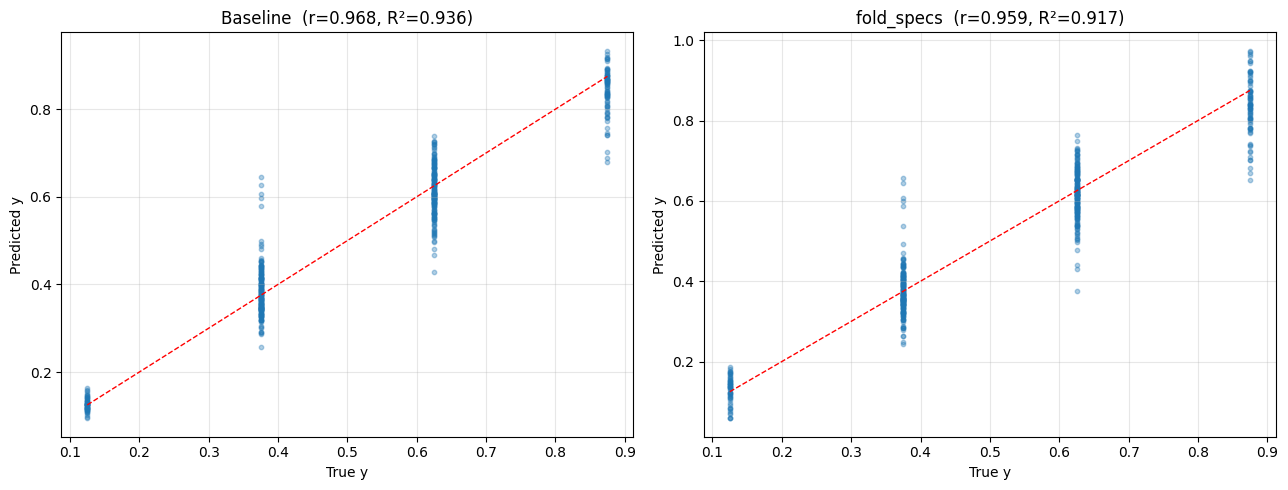

In [5]:
import matplotlib.pyplot as plt

def evaluate(model, X_test, y_true, label):
    preds = model.predict(X_test) / (1 << 30)
    corr = np.corrcoef(preds, y_true)[0, 1]
    ss_res = np.sum((y_true - preds) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot
    print(f"{label:30s}  Pearson r={corr:.4f}  R²={r2:.4f}")
    return preds, corr, r2

preds_baseline, r_b, r2_b = evaluate(model_baseline, X_test, y_test_true, "Baseline (nfolds=4, nfeatsets=2)")
preds_fs,       r_fs, r2_fs = evaluate(model_fs,       X_test, y_test_true, "fold_specs (2 specs × 2 folds)")

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, label, r, r2 in [
    (axes[0], preds_baseline, "Baseline",   r_b,  r2_b),
    (axes[1], preds_fs,       "fold_specs", r_fs, r2_fs),
]:
    ax.scatter(y_test_true, preds, alpha=0.35, s=10)
    lo, hi = y_test_true.min(), y_test_true.max()
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlabel("True y")
    ax.set_ylabel("Predicted y")
    ax.set_title(f"{label}  (r={r:.3f}, R²={r2:.3f})")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
